# Connector-lane offline MILP -- usage example

Builds and solves the model from `offline_cl_opt` (Section 4, "the optimisation model", of `connector_lane_model.html`) on a small toy instance, then compares it against a FIFO simulation on the same arrivals -- see `offline_cl_opt/README.md` for the formulation and scope.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

from offline_cl_opt import (
    StationSpec,
    build_cl_model,
    solve_cl_model,
    vehicles_from_evs,
)
from offline_cl_opt.solution import extract_solution
from toy_demo.scenario import ToyEVSpec, ToyStationSpec, build_evs
from toy_demo.runner import run_toy_episode

## The instance

Same station/EV shape as `offline_opt`'s toy example, so the two packages' bounds can be compared on like-for-like arrivals. `n_connectors` on `ToyStationSpec` becomes `n_connectors` here -- same physical thing, `offline_cl_opt` just uses the source document's own name for it.

In [3]:
STATION = ToyStationSpec(n_piles=2, n_connectors=2, n_modules=5, p_module=25.0)

EV_SPECS = [
    ToyEVSpec(id=0, arrival_time=0.0, battery_kwh=50.0, s_i=0.20, s_f=0.80),
    ToyEVSpec(id=1, arrival_time=2.0, battery_kwh=100.0, s_i=0.15, s_f=0.85),
    ToyEVSpec(id=2, arrival_time=8.0, battery_kwh=50.0, s_i=0.25, s_f=0.75),
    ToyEVSpec(id=3, arrival_time=12.0, battery_kwh=150.0, s_i=0.10, s_f=0.80),
]

cl_station = StationSpec(
    n_piles=STATION.n_piles,
    n_connectors=STATION.n_connectors,
    n_modules=STATION.n_modules,
    p_module=STATION.p_module,
)
vehicles = vehicles_from_evs(build_evs(EV_SPECS))
vehicles

[VehicleData(id=0, a=0.0, Q=50.0, s_i=0.2, s_f=0.8, s_th=0.4, p_max=100.0),
 VehicleData(id=1, a=2.0, Q=100.0, s_i=0.15, s_f=0.85, s_th=0.4, p_max=200.0),
 VehicleData(id=2, a=8.0, Q=50.0, s_i=0.25, s_f=0.75, s_th=0.4, p_max=100.0),
 VehicleData(id=3, a=12.0, Q=150.0, s_i=0.1, s_f=0.8, s_th=0.4, p_max=300.0)]

## Build and solve (exact model, Section 4)

`delta=1.0` minute slots; `horizon_minutes` generous enough that nobody is truncated (check `solution.per_vehicle["served"]` below).

The exact model alone -- no Section 8/10 refinements (adaptive module integrality, symmetry breaking) -- gets no help from the solver beyond the base formulation, so even this small 4-vehicle instance can take several minutes to *prove* optimality (observed: ~12 minutes to 0% gap). `time_limit` below caps that; a `status` of `TIME_LIMIT` with a small `mip_gap` printed is still a good, just not certified-optimal, answer. This cost is exactly what Sections 8 and 10 exist to cut down -- see `offline_cl_opt/README.md`, "Scope".

In [ ]:
cl_model = build_cl_model(vehicles, cl_station, delta=1.0, horizon_minutes=90.0)
solve_cl_model(cl_model, mip_gap=1e-4, time_limit=120.0, verbose=False)
solution = extract_solution(cl_model)

print(f"status={solution.status}, gap={solution.mip_gap:.2%}, runtime={solution.runtime:.2f}s")
print(f"objective (sum D_j) = {solution.objective:.3f} slots, mean sojourn = {solution.mean_sojourn:.3f} min")
solution.per_vehicle

## Sanity check: OPT never exceeds a causal FIFO simulation

Same arrivals, run through the DES with FIFO queueing / proportional power sharing. Because the offline model schedules with full knowledge of every arrival, its total sojourn must never exceed FIFO's -- see `offline_cl_opt/README.md` and `tests/test_connector_lane_optimization.py::test_offline_bound_never_exceeds_fifo_simulation`.

In [4]:
env = run_toy_episode(STATION, EV_SPECS, seed=0, policy_seed=1)
fifo_sojourns = {
    ev.id: ev.departure_time - ev.arrival_time
    for ev in env.engine.metrics.finished_evs
}
fifo_total = sum(fifo_sojourns.values())
#opt_total = float(solution.per_vehicle["sojourn_min"].sum())

print("=== FIFO simulation ===")
for vid in sorted(fifo_sojourns):
    print(f"  vehicle {vid}: sojourn = {fifo_sojourns[vid]:.2f} min")
print(f"  total sojourn = {fifo_total:.2f} min\n")

#print(f"OPT total sojourn ({opt_total:.2f}) <= FIFO total sojourn ({fifo_total:.2f}): {opt_total <= fifo_total}")

=== FIFO simulation ===
  vehicle 0: sojourn = 39.59 min
  vehicle 1: sojourn = 44.10 min
  vehicle 2: sojourn = 44.35 min
  vehicle 3: sojourn = 56.33 min
  total sojourn = 184.37 min



## Section 8: adaptive module integrality

`solve_cl_model_adaptive` solves `CL_R` (modules relaxed to continuous), tests every pile-slot's rounding requirement, promotes only the pile-slots that fail to actually integer, and re-solves the *same* live model in place (so Gurobi can reuse the previous LP basis at the root -- see `offline_cl_opt/README.md`, "Adaptive module integrality"). Its answer is exactly optimal for the fully-integer exact model (Proposition 3), not a heuristic approximation -- `result.objective_history` should land on the same objective `solution.objective` did above, usually much faster.

In [ ]:
from offline_cl_opt import solve_cl_model_adaptive

result = solve_cl_model_adaptive(vehicles, cl_station, delta=1.0, break_symmetry=True,
                        progress=True, bound_departures=True,
                        horizon_minutes=90.0, mip_gap=1e-4,
                        warm_start_from_conservative=False)
adaptive_solution = extract_solution(result.cl_model)

print(f"converged={result.converged}, iterations={result.iterations}")
print(f"objective history: {result.objective_history}")
print(f"pile-slots promoted to integer: {len(result.integer_pile_slots)}")
print(f"adaptive objective = {adaptive_solution.objective:.3f} slots, mean sojourn = {adaptive_solution.mean_sojourn:.3f} min")
adaptive_solution.per_vehicle

## Symmetry breaking (current Section 10)

All piles -- and, within a pile, all connectors -- are identical, so a solution has many relabelled twins. `break_symmetry=True` adds constraints (25)-(26) forcing piles/connectors to be used in order of the lowest-id vehicle occupying them; never changes the optimum, only how many equivalent labelings the solver has to consider. See `offline_cl_opt/README.md`, "Symmetry breaking" -- off by default here since the source document notes it can interfere with warm starts, which matters for the adaptive procedure above.

In [ ]:
cl_model_sym = build_cl_model(vehicles, cl_station, delta=1.0, horizon_minutes=90.0, break_symmetry=True)
solve_cl_model(cl_model_sym, mip_gap=1e-4, time_limit=120.0, verbose=False)

print(f"break_symmetry=False: nodes={cl_model.model.NodeCount:.0f}")
print(f"break_symmetry=True:  nodes={cl_model_sym.model.NodeCount:.0f}, objective={cl_model_sym.model.ObjVal:.3f}")

## Preprocessing (current Section 9)

Section 9.1 computes each vehicle's earliest possible departure (`earliest_departures`); Section 9.2 explains what a known feasible schedule's total departure slots (`UB`, from `incumbent_departure_total`) is actually used for -- *not* narrowing which variables get built (an earlier revision of this package did that, and the current document explicitly argues against it in the congested regime this model targets), but instead as an **objective cutoff** and a **MIP start**. Two ways to supply the feasible-schedule incumbent behind `UB` -- pass a real reference schedule's departure times (e.g. from the FIFO simulation already run above), or omit `incumbent_departures` to fall back to Section 8.4's conservative shortcut automatically. See `offline_cl_opt/README.md`, "Preprocessing".

In [ ]:
from offline_cl_opt import incumbent_departure_total

# Reuse the FIFO simulation from the sanity-check section above as the incumbent.
sim_departures = {ev.id: ev.departure_time for ev in env.engine.metrics.finished_evs}
UB = incumbent_departure_total(vehicles, cl_station, delta=1.0, horizon_minutes=90.0,
                                incumbent_departures=sim_departures)
print("UB (objective cutoff):", UB)

cl_model_cutoff = build_cl_model(vehicles, cl_station, delta=1.0, horizon_minutes=90.0, break_symmetry=True)
solve_cl_model(cl_model_cutoff, mip_gap=1e-4, time_limit=240.0, verbose=False, cutoff=UB)
cutoff_solution = extract_solution(cl_model_cutoff)


In [ ]:
print(f"objective (base exact model) = {solution.objective:.3f}")
print(f"objective (with cutoff)      = {cutoff_solution.objective:.3f} (must match -- cutoff never changes the optimum)")

## Visualizing the solution

`plot_vehicle_power_and_modules` / `plot_pile_power_and_modules` mirror the usage in `offline_opt.ipynb`, adapted for this package's own decision variables (see `offline_cl_opt/visualization.py`'s module docstring for exactly what changed -- notably, connector identity is a real decision here, `y[j,m,c]`, not something reassigned for display the way `offline_opt` has to). Both read straight off a *solved* `ConnectorLaneModel` -- using the base `cl_model` from the "Build and solve" section above.

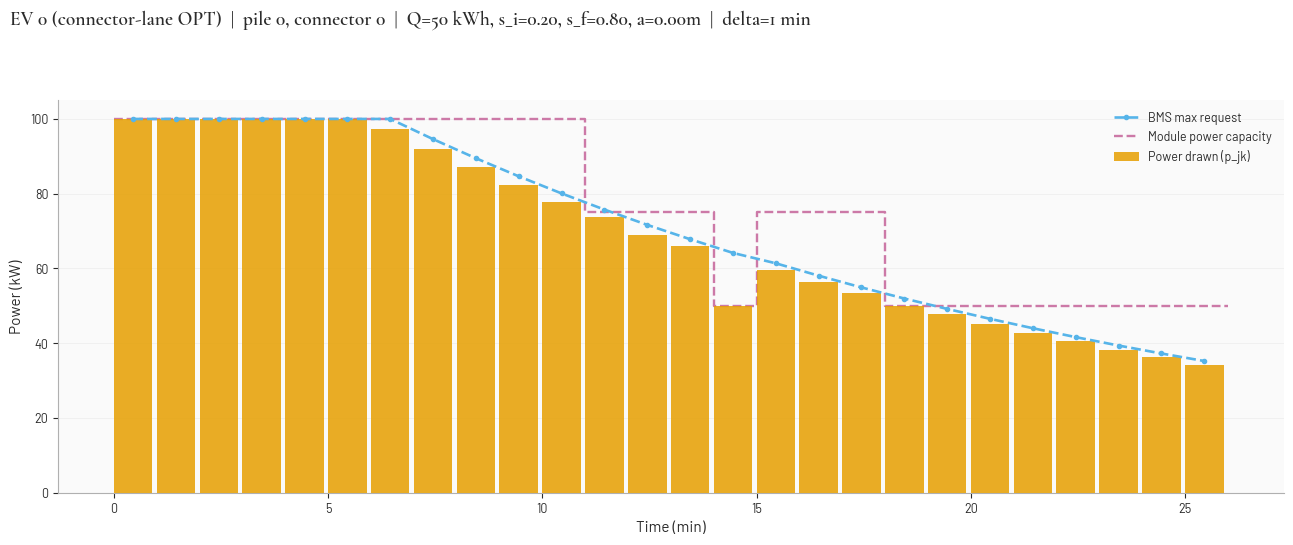

In [14]:
from offline_cl_opt import plot_vehicle_power_and_modules
import matplotlib.pyplot as plt

# One figure per vehicle: power drawn (bars), reconstructed BMS request (dashed),
# and the module power capacity that draw genuinely requires (dashed step).
figs = plot_vehicle_power_and_modules(cl_model, [v.id for v in vehicles])
figs[0]

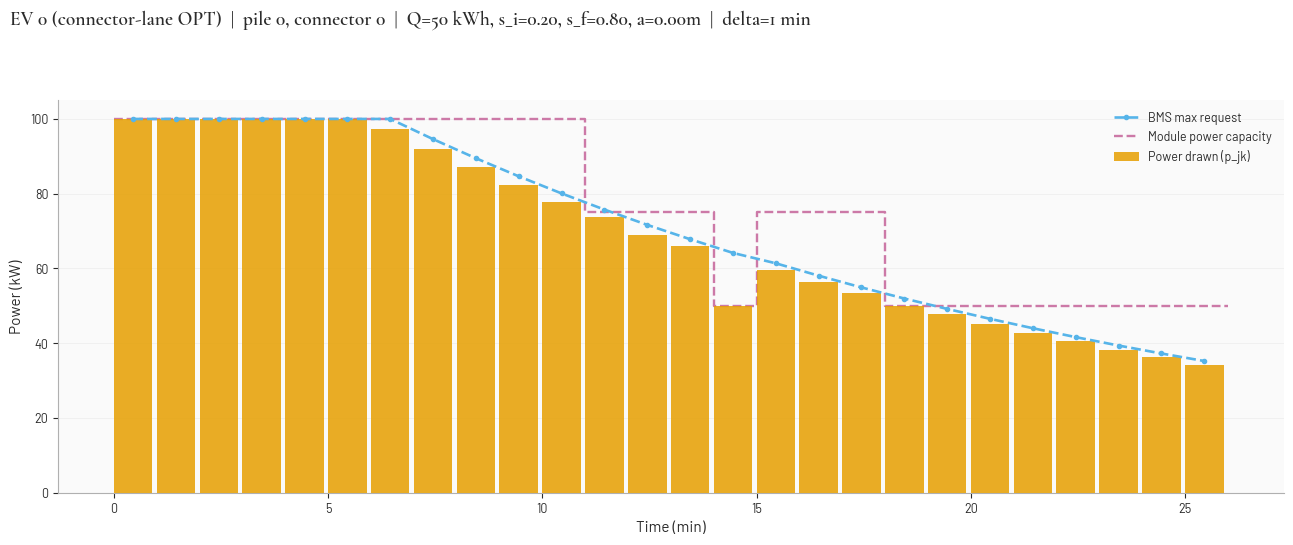

In [15]:
figs[0]

`plot_pile_power_and_modules` -- one subplot per connector on the pile, with toggles to stack the other connectors' draw on top (so bar height reads as the pile's total draw) and to draw a reference line at the pile's total module capacity.

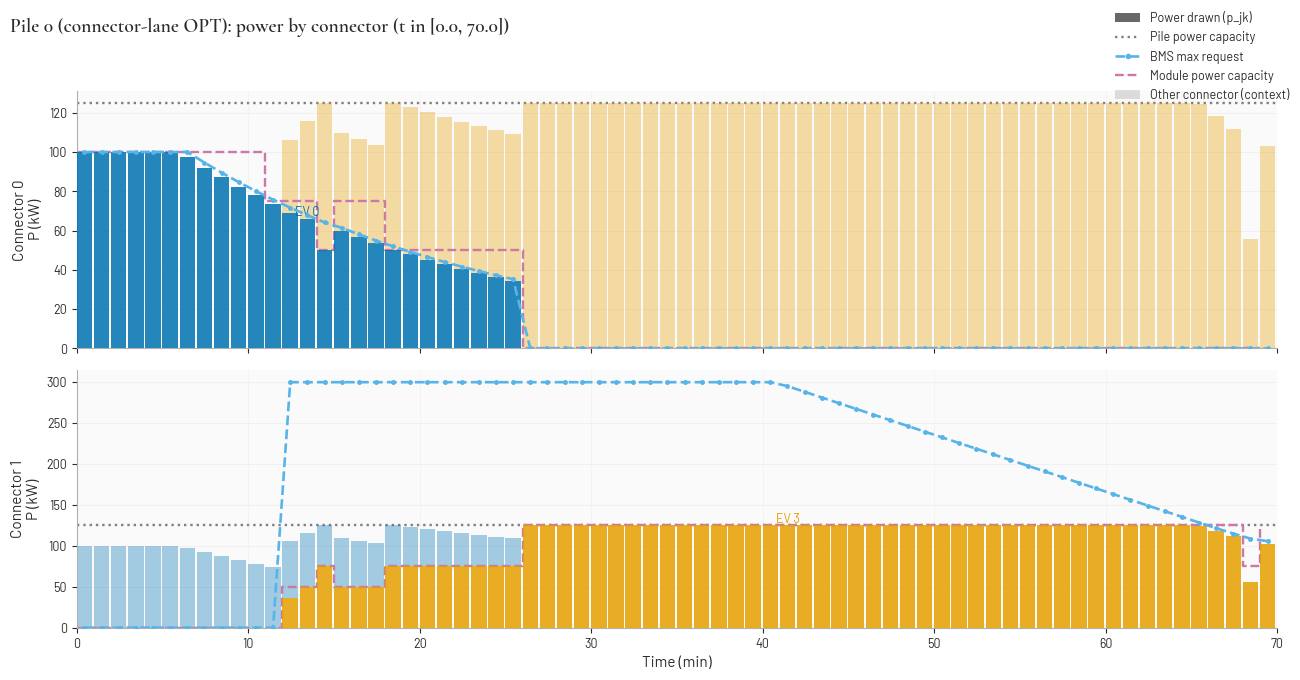

In [8]:
from offline_cl_opt import plot_pile_power_and_modules
import matplotlib.pyplot as plt

plot_pile_power_and_modules(cl_model, pile_id=0, stack_other_connectors=True, show_pile_capacity=True)

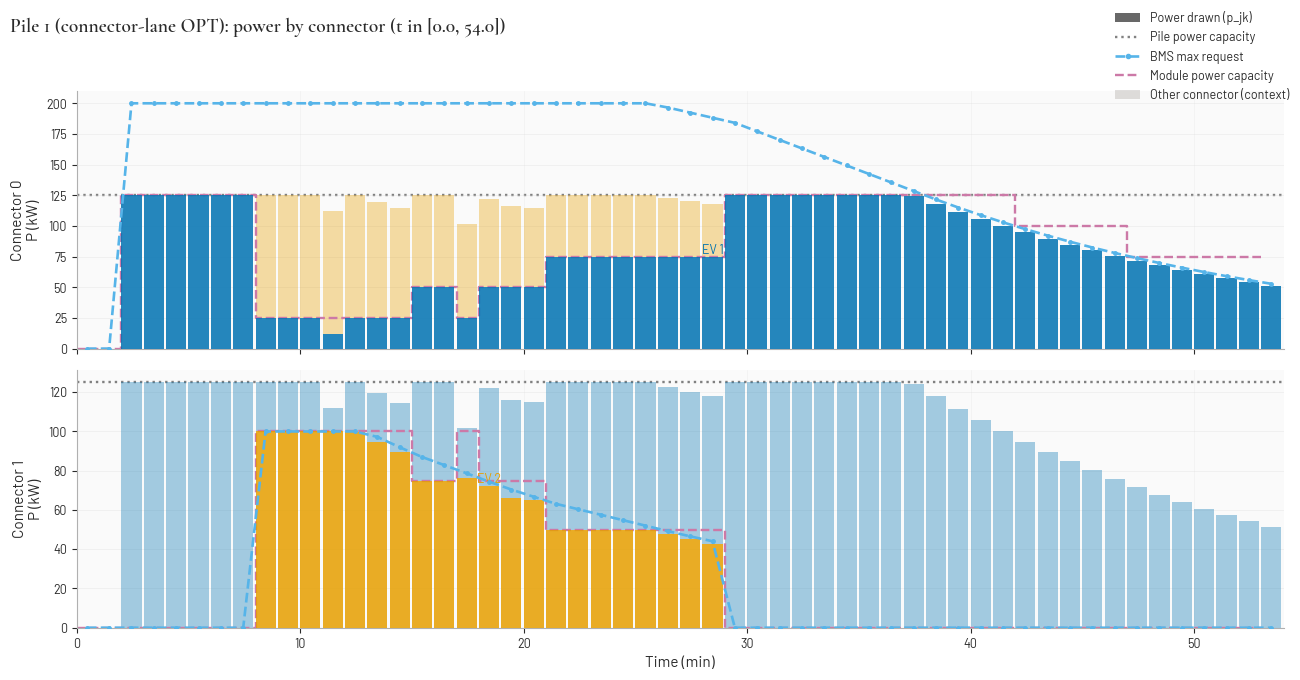

In [9]:
plot_pile_power_and_modules(cl_model, pile_id=1, stack_other_connectors=True, show_pile_capacity=True)

## Dantzig-Wolfe decomposition (`offline_cl_dw`)

Everything above solves the compact model directly. On a large instance even the adaptive/relaxed compact model can be slow, because its linear relaxation is structurally weak in two places: the big-M pairwise sequencing rows (11)-(12), and a departure rule that can relax into reporting a departure time far below anything achievable. `offline_cl_dw` decomposes the model **by vehicle** instead -- a master problem picks one whole-schedule "plan" per vehicle from a pool generated on demand by per-(vehicle, pile) pricing subproblems (column generation), which removes both weaknesses structurally. See `offline_cl_dw/README.md`, "Why bother", for the full argument.

The deliverable here is a **bracket**: `solve_by_decomposition` runs column generation for a certified lower bound, then price-and-branch (one small integer solve over the columns already generated) for a feasible upper bound -- not necessarily a single certified optimum. `progress=True` prints one line per column-generation iteration.

In [ ]:
from offline_cl_dw import solve_by_decomposition

dw_solution, dw_colgen = solve_by_decomposition(
    vehicles, cl_station, delta=1.0, horizon_minutes=90.0, progress=True,
)

print(f"\nbracket: [{dw_solution.lower_bound:.3f}, {dw_solution.upper_bound:.3f}]  "
      f"gap={dw_solution.gap:.3f}  converged={dw_solution.converged}  "
      f"iterations={dw_solution.iterations}")
print(f"compact-model exact objective (from 'Build and solve' above) = {solution.objective:.3f}")
print(f"whole_module_feasible: {dw_solution.whole_module_feasible}")
dw_solution.per_vehicle

`lower_bound` is a certified lower bound on the true optimum, valid even if `converged` is `False` (an *anytime* bound). `upper_bound` is a genuine feasible schedule's cost from price-and-branch, but -- as the source document itself is explicit about -- **not necessarily the true optimum**: the best integer combination can need a column that column generation, chasing only the continuous relaxation's own optimum, never happened to generate. On a small, lightly-contended instance the bracket can come out wide even though the lower bound itself is tight; see `offline_cl_dw/README.md`, "Getting an integer schedule", for a worked example and what to do about it (full branch-and-price, not implemented here, is the documented next step if the gap is too wide for your purposes). Rerunning `solve_by_decomposition(..., extra_seed_columns=...)` seeded from a real simulation's output (`offline_cl_dw.columns_from_evs`, same idea as `warm_start_evs` above) is a cheap way to try tightening it first.

**At larger scale** (many vehicles/piles, or a long horizon), pricing every `(vehicle, pile)` pair -- not the master LP -- is almost always what makes each column-generation iteration slow. Pricers are solved concurrently across a thread pool by default (`max_workers`, `pricer_threads` -- see `offline_cl_dw/README.md`, "Column generation"); on a 30-vehicle/4-pile synthetic instance this cut wall time from 84s to 24s for the same iterations, with byte-identical results. Not worth demonstrating on this notebook's 4-vehicle toy instance (too small to show a difference), but worth knowing about before assuming a slow run needs a bigger algorithmic change.